In [ ]:
import numpy as np                    # Hızlı dört işlem yapmamızı sağlar
import matplotlib.pyplot as plt       # Görsel üretme kütüphanesi
import cv2                            # Görüntü işleme kütüphanesi
from skimage import data              # Hazır görsel kütüphanesi

In [ ]:
resim = data.camera()

array([[200, 200, 200, ..., 189, 190, 190],
       [200, 199, 199, ..., 190, 190, 190],
       [199, 199, 199, ..., 190, 190, 190],
       ...,
       [ 25,  25,  27, ..., 139, 122, 147],
       [ 25,  25,  26, ..., 158, 141, 168],
       [ 25,  25,  27, ..., 151, 152, 149]], dtype=uint8)
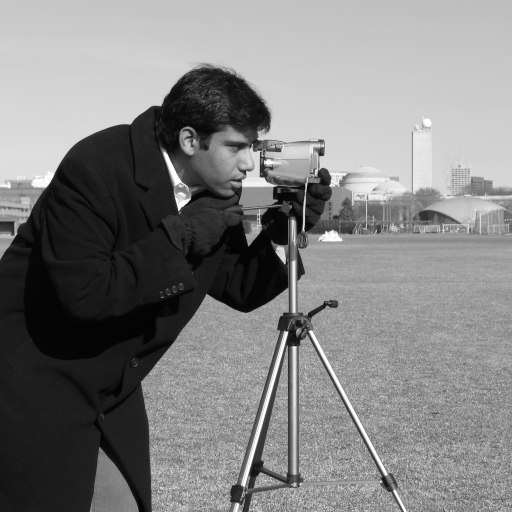

In [ ]:
resim

#Filtre

Teknik olarak bir mercek

In [ ]:
kernel_3x3 = np.ones((3, 3), dtype=np.float32) / 9

Büyük beyaz, küçük siyah

In [ ]:
print(kernel_3x3)

[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]


In [ ]:
bulanik_resim = cv2.filter2D(resim, -1, kernel_3x3) # -> Konvolüsyon

array([[200, 200, 200, ..., 190, 190, 190],
       [199, 199, 200, ..., 190, 190, 190],
       [199, 199, 199, ..., 190, 190, 190],
       ...,
       [ 25,  26,  25, ..., 150, 149, 145],
       [ 25,  26,  25, ..., 147, 147, 144],
       [ 25,  25,  25, ..., 147, 154, 150]], dtype=uint8)
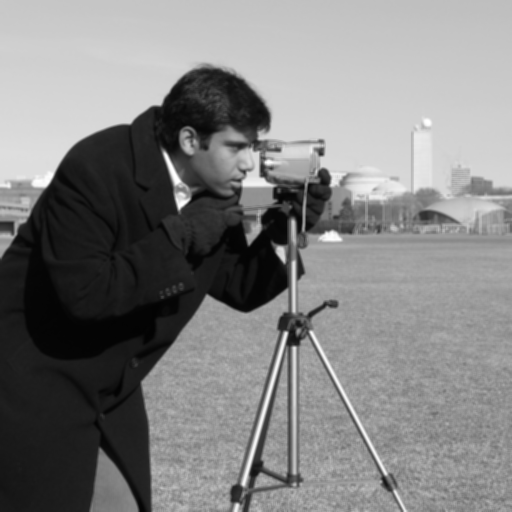

In [ ]:
bulanik_resim

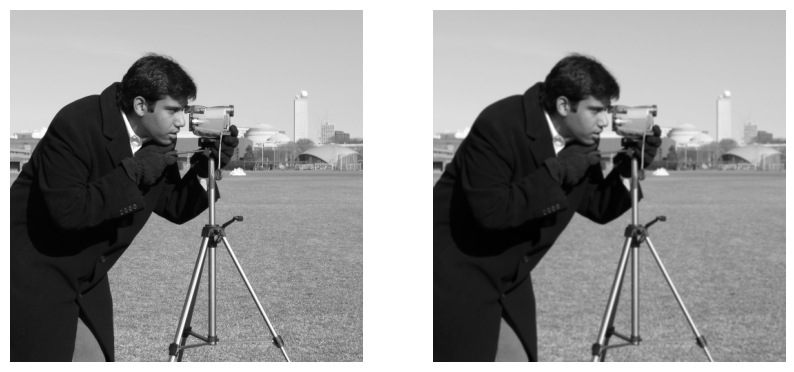

In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(resim, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(bulanik_resim, cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
bulanik_7x7 = cv2.blur(resim, (7, 7))
bulanik_15x15 = cv2.blur(resim, (15, 15))

array([[199, 199, 199, ..., 190, 190, 190],
       [200, 199, 200, ..., 190, 190, 190],
       [200, 199, 200, ..., 190, 190, 190],
       ...,
       [ 25,  25,  25, ..., 143, 143, 146],
       [ 25,  25,  25, ..., 145, 145, 148],
       [ 25,  25,  25, ..., 147, 147, 151]], dtype=uint8)
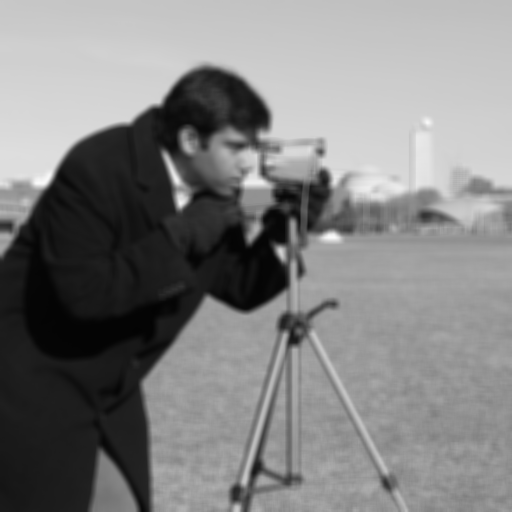

In [ ]:
bulanik_7x7

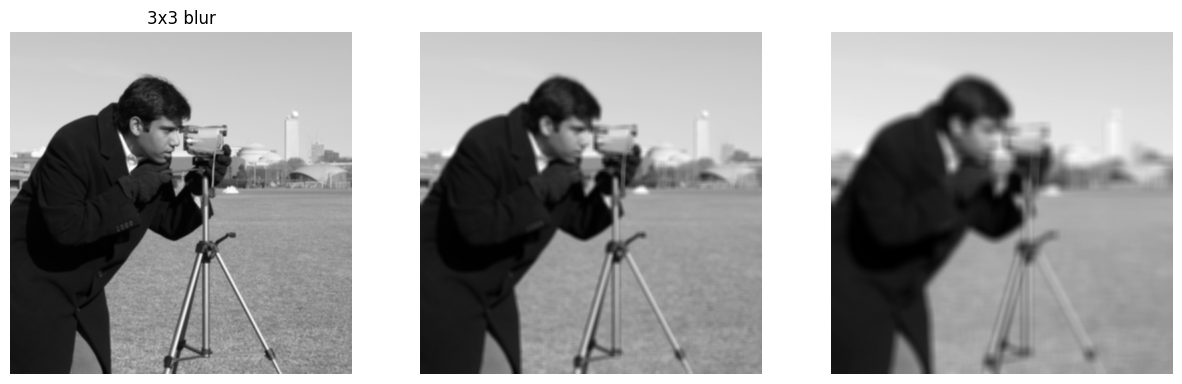

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(bulanik_resim, cmap='gray')
plt.title('3x3 blur')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(bulanik_7x7, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(bulanik_15x15, cmap='gray')
plt.axis('off')

plt.show()

# Noisy - Gürültü

In [ ]:
gurultulu_resim = resim.copy()
satir, sutun = gurultulu_resim.shape

In [ ]:
gurultulu_resim.shape

(512, 512)

In [ ]:
piksel_sayisi = satir * sutun
tuz_miktari = int(piksel_sayisi * 0.05)
biber_miktari = int(piksel_sayisi * 0.05)

In [ ]:
tuz_x = np.random.randint(0, satir, tuz_miktari)
tuz_y = np.random.randint(0, sutun, tuz_miktari)
gurultulu_resim[tuz_x, tuz_y] = 255

In [ ]:
biber_x = np.random.randint(0, satir, biber_miktari)
biber_y = np.random.randint(0, sutun, biber_miktari)
gurultulu_resim[biber_x, biber_y] = 0

array([[200, 200, 200, ..., 189, 190,   0],
       [200, 199, 255, ..., 190, 190, 190],
       [199, 199, 199, ..., 190, 190,   0],
       ...,
       [ 25, 255,  27, ..., 139,   0, 255],
       [  0,   0, 255, ..., 158, 141, 168],
       [ 25,   0,  27, ..., 151, 152,   0]], dtype=uint8)
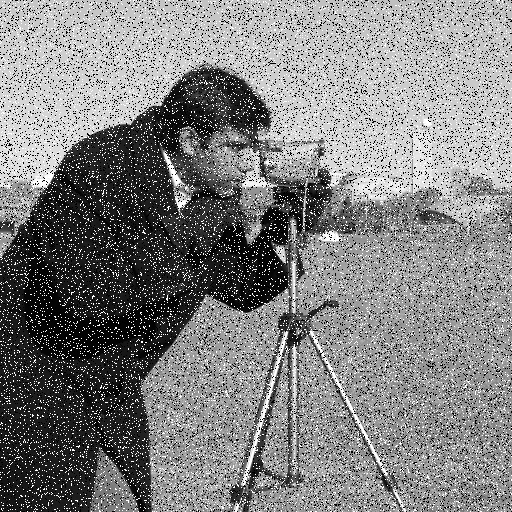

In [ ]:
gurultulu_resim

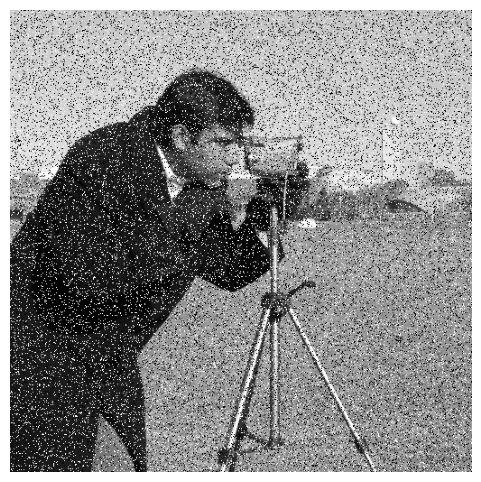

In [ ]:
plt.figure(figsize=(6, 6))
plt.imshow(gurultulu_resim, cmap='gray')
plt.axis('off')
plt.show()

#Temizleme

In [ ]:
mean_temiz = cv2.blur(gurultulu_resim, (5, 5))

In [ ]:
mean_temiz

In [ ]:
median_temiz = cv2.medianBlur(gurultulu_resim, 5)

array([[200, 200, 200, ..., 190, 189, 189],
       [200, 200, 200, ..., 190, 190, 190],
       [200, 200, 200, ..., 190, 190, 190],
       ...,
       [ 25,  25,  25, ..., 144, 151, 151],
       [ 25,  25,  24, ..., 144, 151, 151],
       [ 25,  25,  25, ..., 144, 144, 151]], dtype=uint8)
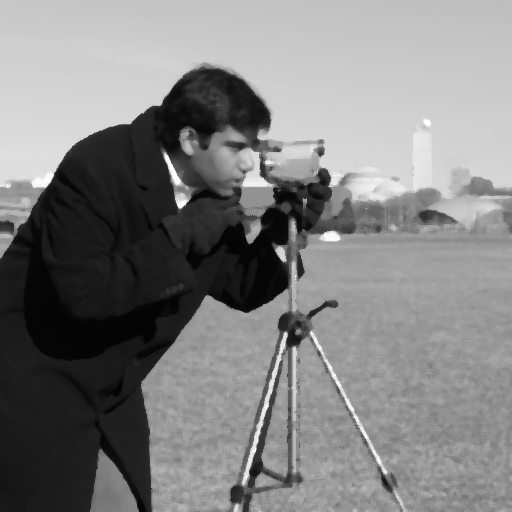

In [ ]:
median_temiz

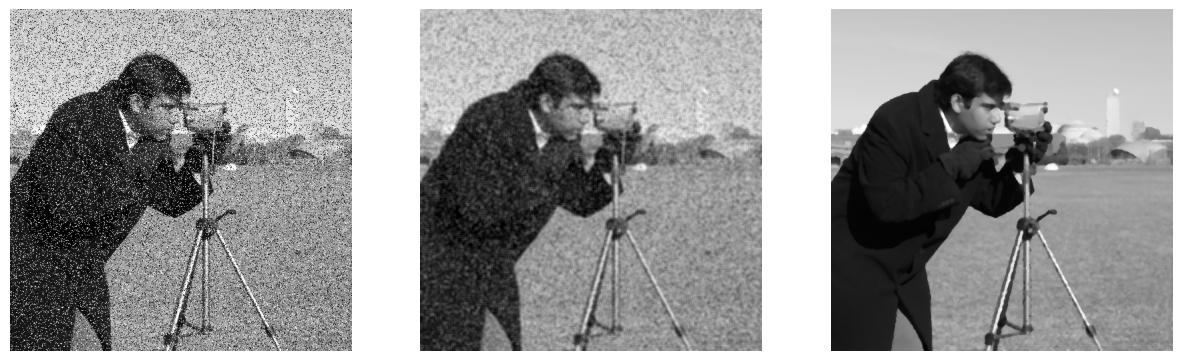

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(gurultulu_resim, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mean_temiz, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(median_temiz, cmap='gray')
plt.axis('off')

plt.show()

#Padding - Dolgu

In [ ]:
kucuk_resim = np.array([
    [20, 50, 50],
    [30, 90, 50],
    [50, 50, 50]
], dtype=np.uint8)

In [ ]:
kucuk_resim

In [ ]:
zero_pad = np.pad(kucuk_resim, pad_width=1, mode='constant', constant_values=0)

In [ ]:
print(zero_pad)

In [ ]:
reflect_pad = np.pad(kucuk_resim, pad_width=1, mode='edge')

In [ ]:
print(reflect_pad)

In [ ]:
siyah_cerceve = cv2.copyMakeBorder(resim, 30, 30, 30, 30, cv2.BORDER_CONSTANT, value=0)

In [ ]:
yansiyan_cerceve = cv2.copyMakeBorder(resim, 30, 30, 30, 30, cv2.BORDER_REPLICATE)

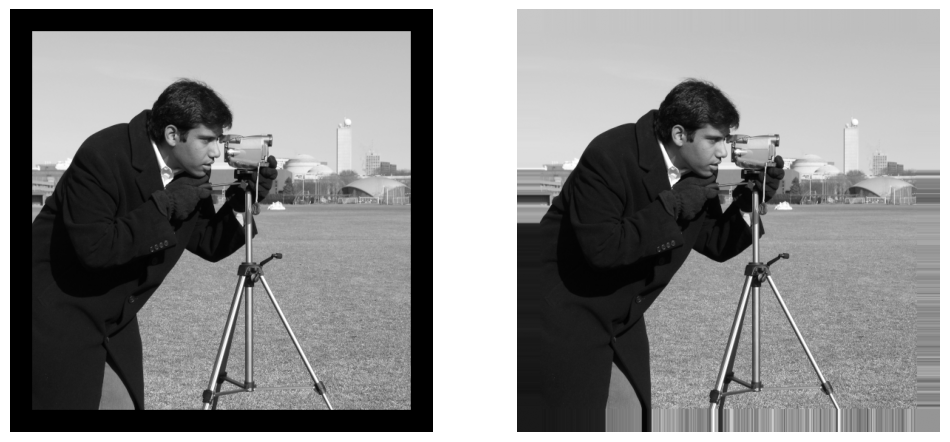

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(siyah_cerceve, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(yansiyan_cerceve, cmap='gray')
plt.axis('off')

plt.show()

Dolgu boyutu genelde (F-1)/2 olarak hesaplanır

#Thresholding - Eşikleme

In [ ]:
giriş_resmi = median_temiz

array([[200, 200, 200, ..., 190, 189, 189],
       [200, 200, 200, ..., 190, 190, 190],
       [200, 200, 200, ..., 190, 190, 190],
       ...,
       [ 25,  25,  25, ..., 144, 151, 151],
       [ 25,  25,  24, ..., 144, 151, 151],
       [ 25,  25,  25, ..., 144, 144, 151]], dtype=uint8)
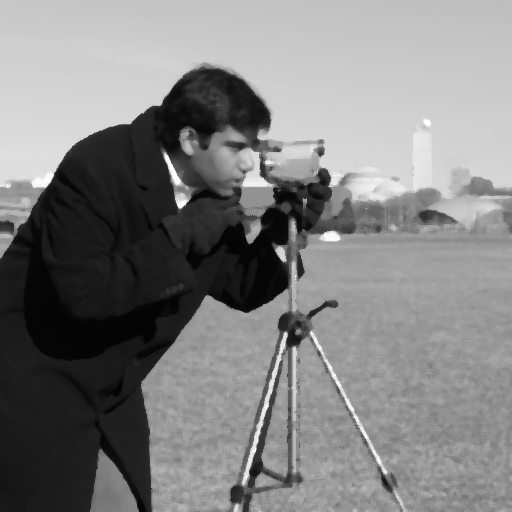

In [ ]:
giriş_resmi

In [ ]:
esik_degeri = 127

In [ ]:
biner_resim = np.where(giriş_resmi > esik_degeri, 255, 0).astype(np.uint8)

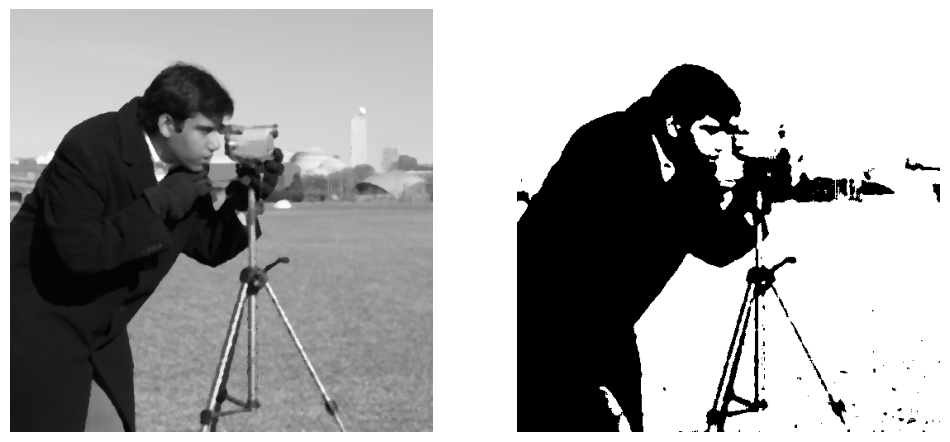

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(giriş_resmi, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(biner_resim, cmap='gray')
plt.axis('off')

plt.show()

In [ ]:
hesaplanan_esik, otsu_resim = cv2.threshold(giriş_resmi, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

In [ ]:
print(hesaplanan_esik)

102.0


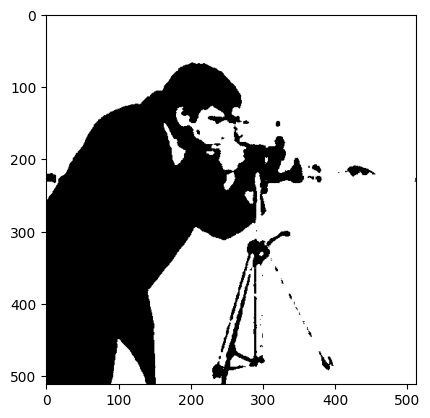

In [ ]:
plt.imshow(otsu_resim, cmap='gray')
plt.show()